# Step 4 — SQL Analytics: What the Job Market Actually Wants

This notebook answers the business questions the project set out to answer, using
real SQL against `data/jobdatadigest.db` (built by `cleaning/clean_and_load.py` and
`nlp/extract_skills.py`). Every result below comes from **4,858 unique postings**
across 6 roles x 6 Indian metros (Delhi + Gurgaon merged into "Delhi NCR").

**Two limitations to hold in mind while reading every result in this notebook:**

1. **Salary figures exist for only ~23% of postings** (1,122 of 4,858). All
   salary-based analysis below is conditioned on that subset, which is a
   self-selected group of employers willing to disclose pay — not necessarily
   representative of the full market.
2. **Skill mentions come from a keyword-matched, 500-character-truncated
   description** (see `nlp/extract_skills.py` for the full precision/recall
   discussion). Skill counts are a systematic *undercount*, useful for relative
   comparison ("X is more commonly mentioned than Y") rather than as an absolute
   count of postings requiring that skill.


In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

DB_PATH = "../data/jobdatadigest.db"
conn = sqlite3.connect(DB_PATH)
pd.set_option("display.width", 120)

# --- shared chart styling (see project dataviz notes) ---
SURFACE = "#fcfcfb"
INK_PRIMARY = "#0b0b0b"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BLUE = "#2a78d6"

# Fixed categorical order for the 6 roles -- assigned once, reused in every
# chart so a given role is always the same color throughout the notebook.
ROLE_ORDER = [
    "Data Analyst", "Business Analyst", "Software Engineer",
    "Data Engineer", "Machine Learning Engineer", "Data Scientist",
]
ROLE_COLORS = dict(zip(ROLE_ORDER, [
    "#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948",
]))

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": GRIDLINE,
    "axes.labelcolor": INK_PRIMARY,
    "text.color": INK_PRIMARY,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "grid.color": GRIDLINE,
    "axes.grid": True,
    "axes.grid.axis": "x",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "font.size": 10,
})


def hbar(df, label_col, value_col, title, color=BLUE, value_fmt="{:,.0f}"):
    """Single-series horizontal bar chart, most valuable at top."""
    df = df.sort_values(value_col)
    fig, ax = plt.subplots(figsize=(7, max(2.5, 0.35 * len(df))))
    bars = ax.barh(df[label_col], df[value_col], color=color, height=0.65)
    for bar, val in zip(bars, df[value_col]):
        ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2,
                f"  {value_fmt.format(val)}", va="center", fontsize=9, color=INK_PRIMARY)
    ax.set_title(title, fontsize=12, color=INK_PRIMARY, loc="left", pad=12)
    ax.set_xlabel("")
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(df[label_col])
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    plt.tight_layout()
    plt.show()


## 1. Top in-demand skills — overall and per role

**Business question:** what should a job-seeker learn first if they want to be
broadly employable across this market?


In [2]:
top_skills_overall = pd.read_sql_query('''
    SELECT skill, COUNT(DISTINCT posting_id) AS n,
           ROUND(100.0 * COUNT(DISTINCT posting_id) / (SELECT COUNT(*) FROM postings), 1) AS pct_of_postings
    FROM posting_skills
    GROUP BY skill
    ORDER BY n DESC
    LIMIT 12
''', conn)
top_skills_overall

,skill,n,pct_of_postings
0,Machine Learning,589,12.1
1,Python,485,10.0
2,SQL,430,8.9
3,ETL,213,4.4
4,AWS,212,4.4
5,Spark,197,4.1
6,Java,196,4.0
7,Azure,178,3.7
8,Agile,125,2.6
9,GCP,111,2.3


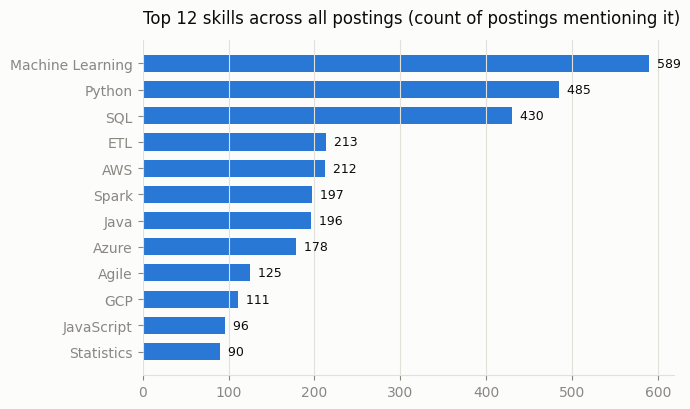

In [3]:
hbar(top_skills_overall, "skill", "n", "Top 12 skills across all postings (count of postings mentioning it)")

**Insight:** Machine Learning is the single most-mentioned skill overall (589
postings, 12.1%), narrowly ahead of Python (485, 10.0%) and SQL (430, 8.9%) — a
sign that "ML" now shows up as a buzzword even in postings outside dedicated
ML/Data Scientist roles. For a fresher deciding what to learn first, **Python and
SQL are the safest bets**: they are the only two skills that place in the top 4
for nearly every role individually (see below), making them the most
role-agnostic investment in this market.


In [4]:
top_skills_per_role = pd.read_sql_query('''
    SELECT primary_role, skill, n FROM (
        SELECT p.primary_role, ps.skill, COUNT(*) AS n,
               ROW_NUMBER() OVER (PARTITION BY p.primary_role ORDER BY COUNT(*) DESC) AS rnk
        FROM postings p JOIN posting_skills ps ON p.posting_id = ps.posting_id
        GROUP BY p.primary_role, ps.skill
    ) WHERE rnk <= 4
    ORDER BY primary_role, rnk
''', conn)
top_skills_per_role

,primary_role,skill,n
0,Business Analyst,SQL,43
1,Business Analyst,Agile,42
2,Business Analyst,Java,20
3,Business Analyst,Excel,18
4,Data Analyst,SQL,103
5,Data Analyst,Python,54
6,Data Analyst,Power BI,47
7,Data Analyst,ETL,43
8,Data Engineer,Python,165
9,Data Engineer,SQL,162


**Insight:** skill demand is sharply role-specific, not a generic pool.
Data Analyst leads with **SQL, Python, Power BI, ETL**; Data Engineer leads with
**Python, SQL, ETL, AWS** (the "cloud pipeline" cluster); Data Scientist and
Machine Learning Engineer both lead with **Machine Learning** itself, followed by
Python and Deep Learning. **Software Engineer is the outlier**: its top 4 —
Java, JavaScript, React, .NET — shares zero overlap with any other role's top 4,
confirming SWE draws from a genuinely different skill pool than the
data-and-analytics-flavored roles in this dataset. A Business Analyst candidate
should prioritize SQL and Agile literacy over BI-tool depth — Excel (18 mentions)
and Power BI barely register compared to SQL (43) and Agile (42) for that role.


## 2. Skill co-occurrence — which tools travel together

**Business question:** if a candidate already knows one tool, which second tool
gives them the most leverage?


In [5]:
co_occurrence = pd.read_sql_query('''
    SELECT a.skill AS skill_a, b.skill AS skill_b, COUNT(*) AS co_occurrences
    FROM posting_skills a
    JOIN posting_skills b ON a.posting_id = b.posting_id AND a.skill < b.skill
    GROUP BY a.skill, b.skill
    ORDER BY co_occurrences DESC
    LIMIT 12
''', conn)
co_occurrence

,skill_a,skill_b,co_occurrences
0,Python,SQL,196
1,Python,Spark,131
2,Machine Learning,Python,120
3,ETL,SQL,99
4,SQL,Spark,97
5,AWS,Python,91
6,ETL,Python,73
7,Azure,SQL,70
8,AWS,SQL,68
9,Deep Learning,Machine Learning,62


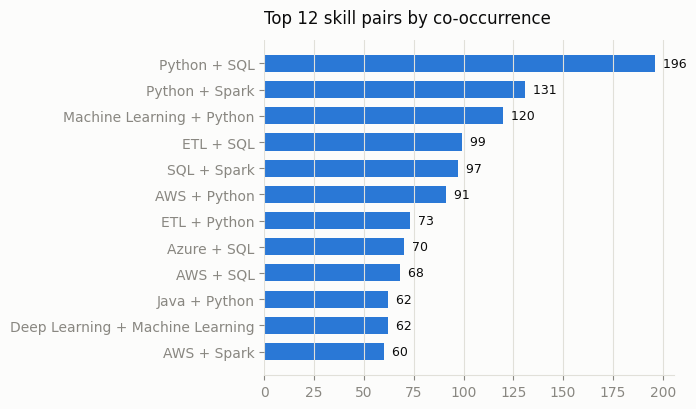

In [6]:
pairs = co_occurrence.assign(pair=lambda d: d.skill_a + " + " + d.skill_b)
hbar(pairs, "pair", "co_occurrences", "Top 12 skill pairs by co-occurrence")

**Insight:** Python + SQL is the single most common pairing (196
co-occurrences) — well ahead of Python + Spark (131) and Machine Learning +
Python (120). This confirms Python and SQL function as a **joint baseline
literacy** across roles rather than substitutes for one another; a candidate
who only learns one is leaving the more common combination on the table. The
next tier — Spark, AWS, and ETL all pairing heavily with Python/SQL — traces
the Data Engineer "cloud pipeline" cluster identified in Section 1, which shows
up here as a cohesive block of tools that are almost always requested together.


## 3. Salary bands — by role, city, and seniority

**Business question:** does the role you target, the city you target, or your
seniority matter more for pay? (All figures below are annual INR, restricted to
the 1,122 postings that disclose a plausible salary — see the cleaning notes in
`cleaning/config.py` for how implausible figures, e.g. monthly stipends
mis-entered as annual pay, were filtered out.)


In [7]:
salary_by_role = pd.read_sql_query('''
    SELECT primary_role, COUNT(*) AS n, ROUND(AVG(salary_avg)) AS avg_salary
    FROM postings WHERE has_salary = 1
    GROUP BY primary_role ORDER BY avg_salary DESC
''', conn)
salary_by_role

,primary_role,n,avg_salary
0,Machine Learning Engineer,92,1759998.0
1,Data Scientist,254,1583553.0
2,Data Engineer,246,1577439.0
3,Software Engineer,263,1375209.0
4,Data Analyst,112,1319375.0
5,Business Analyst,155,1155139.0


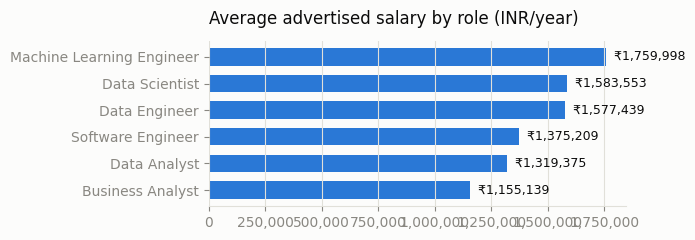

In [8]:
hbar(salary_by_role, "primary_role", "avg_salary",
     "Average advertised salary by role (INR/year)", value_fmt="₹{:,.0f}")

**Insight:** Machine Learning Engineer commands the highest average
advertised salary (₹17.6L), with Data Scientist and Data Engineer close behind
(~₹15.8L each) — the three most data/ML-heavy roles cluster at the top.
Business Analyst is the lowest-paid role on average (₹11.6L), about **34% below**
ML Engineer. That's a ~₹6L annual spread driven by role choice alone, among
roles all targeting a similar fresher-to-mid experience band.


In [9]:
salary_by_city = pd.read_sql_query('''
    SELECT city, COUNT(*) AS n, ROUND(AVG(salary_avg)) AS avg_salary
    FROM postings WHERE has_salary = 1
    GROUP BY city ORDER BY avg_salary DESC
''', conn)
salary_by_city

,city,n,avg_salary
0,Chennai,130,1582769.0
1,Bangalore,269,1529925.0
2,Pune,174,1452810.0
3,Delhi NCR,242,1425579.0
4,Hyderabad,106,1390896.0
5,Mumbai,201,1383905.0


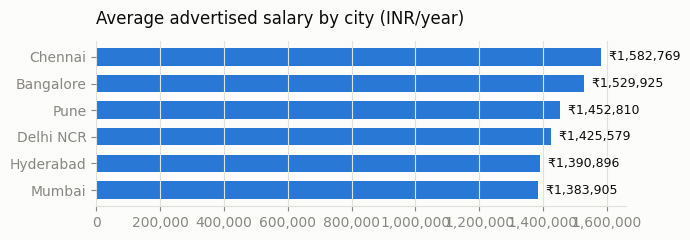

In [10]:
hbar(salary_by_city, "city", "avg_salary", "Average advertised salary by city (INR/year)", value_fmt="₹{:,.0f}")

**Insight:** city-level salary variation (~₹1.5-2L range, Chennai ₹15.8L to
Hyderabad/Mumbai ~₹13.8-13.9L) is **much smaller than role-level variation**
(~₹6L range). Practically: which of these six roles you target matters far more
for expected pay than which of these six metros you target.


In [11]:
salary_by_seniority = pd.read_sql_query('''
    SELECT seniority, COUNT(*) AS n, ROUND(AVG(salary_avg)) AS avg_salary
    FROM postings WHERE has_salary = 1 AND seniority != 'Unknown'
    GROUP BY seniority
    ORDER BY CASE seniority WHEN 'Junior' THEN 1 WHEN 'Mid' THEN 2 WHEN 'Senior' THEN 3 END
''', conn)
salary_by_seniority

,seniority,n,avg_salary
0,Junior,48,701458.0
1,Mid,129,1462791.0
2,Senior,336,1727072.0


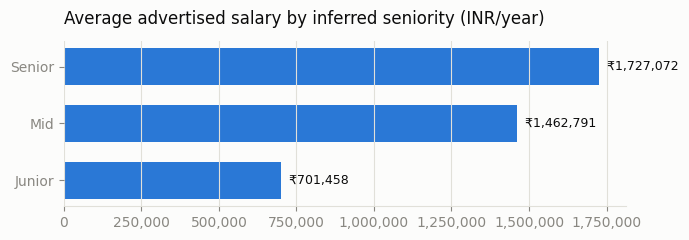

In [12]:
order = ["Junior", "Mid", "Senior"]
df = salary_by_seniority.set_index("seniority").loc[order].reset_index()
hbar(df.iloc[::-1], "seniority", "avg_salary", "Average advertised salary by inferred seniority (INR/year)", value_fmt="₹{:,.0f}")

**Insight:** the inferred seniority label (see `nlp/seniority.py`) tracks
salary cleanly and monotonically — Junior ₹7.0L, Mid ₹14.6L (2.1x junior),
Senior ₹17.3L (2.5x junior). This is also a useful **sanity check on the NLP
rule itself**: if the seniority inference were mostly noise, we would not expect
such an orderly salary gradient to fall out of it.


In [13]:
same_role_by_city = pd.read_sql_query('''
    SELECT city, COUNT(*) AS n, ROUND(AVG(salary_avg)) AS avg_salary
    FROM postings WHERE has_salary = 1 AND primary_role = 'Data Analyst'
    GROUP BY city ORDER BY avg_salary DESC
''', conn)
same_role_by_city

,city,n,avg_salary
0,Pune,19,1828947.0
1,Mumbai,27,1307407.0
2,Bangalore,39,1260256.0
3,Chennai,12,1145833.0
4,Hyderabad,9,1011111.0
5,Delhi NCR,6,953333.0


**Insight:** holding role fixed (Data Analyst only) to make a fair city
comparison, Pune pays the most on average (₹18.3L, n=19) and Delhi NCR the
least (₹9.5L, n=6) — nearly a 2x gap for the identical title. **Caveat:** these
per-role-per-city cells have small sample sizes (6-39 postings), so this should
be read as a directional signal worth re-checking on a larger pull, not a
confident city ranking.


## 4. Which skills correlate with higher salary

**Business question:** beyond role choice, which specific skills are associated
with an above-average paycheck?


In [14]:
overall_avg_salary = pd.read_sql_query(
    "SELECT ROUND(AVG(salary_avg)) AS a FROM postings WHERE has_salary = 1", conn
).iloc[0, 0]

skill_salary = pd.read_sql_query('''
    SELECT ps.skill, COUNT(*) AS n, ROUND(AVG(p.salary_avg)) AS avg_salary_with_skill
    FROM postings p JOIN posting_skills ps ON p.posting_id = ps.posting_id
    WHERE p.has_salary = 1
    GROUP BY ps.skill
    HAVING COUNT(*) >= 15
    ORDER BY avg_salary_with_skill DESC
    LIMIT 12
''', conn)
print(f"Overall average salary across all salaried postings: Rs {overall_avg_salary:,.0f}")
skill_salary

Overall average salary across all salaried postings: Rs 1,462,290


,skill,n,avg_salary_with_skill
0,Airflow,16,1925000.0
1,GCP,32,1889844.0
2,Deep Learning,37,1811622.0
3,TensorFlow,15,1741000.0
4,Machine Learning,169,1645768.0
5,React,41,1590854.0
6,Snowflake,19,1589474.0
7,Python,198,1583005.0
8,Azure,48,1550521.0
9,Node.js,28,1539286.0


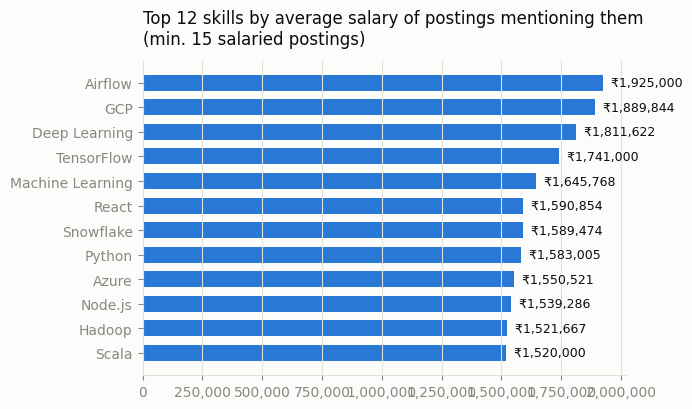

In [15]:
hbar(skill_salary, "skill", "avg_salary_with_skill",
     "Top 12 skills by average salary of postings mentioning them\n(min. 15 salaried postings)",
     value_fmt="₹{:,.0f}")

**Insight:** among skills with at least 15 salaried postings, **Airflow
(₹19.3L), GCP (₹18.9L), and Deep Learning (₹18.1L)** top the list — all well
above the ₹14.6L average across all salaried postings. These are exactly the
"senior data engineering / ML infrastructure" skills, consistent with the
role-level finding that ML/Data Engineering out-earns analyst-facing roles.
**Important caveat:** this is a cross-sectional correlation, not a causal claim
— postings that require Airflow or GCP likely also require more years of
experience, which independently drives salary up. The honest takeaway is
"these skills travel with higher-paying postings," not "learning Airflow adds
₹5L to your salary."


## 5. City-wise role concentration — where is which role actually hiring

**Business question:** if I'm committed to a specific role, which city has the
deepest market for it (proportionally, not just in raw count)?


In [16]:
city_role_share = pd.read_sql_query('''
    SELECT city, primary_role, COUNT(*) AS n,
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY city), 1) AS pct_within_city
    FROM postings
    GROUP BY city, primary_role
''', conn)

pivot = city_role_share.pivot(index="city", columns="primary_role", values="pct_within_city")[ROLE_ORDER]
pivot

primary_role,Data Analyst,Business Analyst,Software Engineer,Data Engineer,Machine Learning Engineer,Data Scientist
city,,,,,,
Bangalore,16.7,16.8,16.8,16.8,16.8,16.0
Chennai,14.9,19.3,21.0,19.3,6.4,19.1
Delhi NCR,5.5,11.9,27.1,21.4,3.2,30.9
Hyderabad,15.9,15.9,17.3,17.4,17.5,16.0
Mumbai,16.8,20.3,20.0,18.4,5.7,18.9
Pune,16.4,17.9,19.6,19.2,10.1,16.8


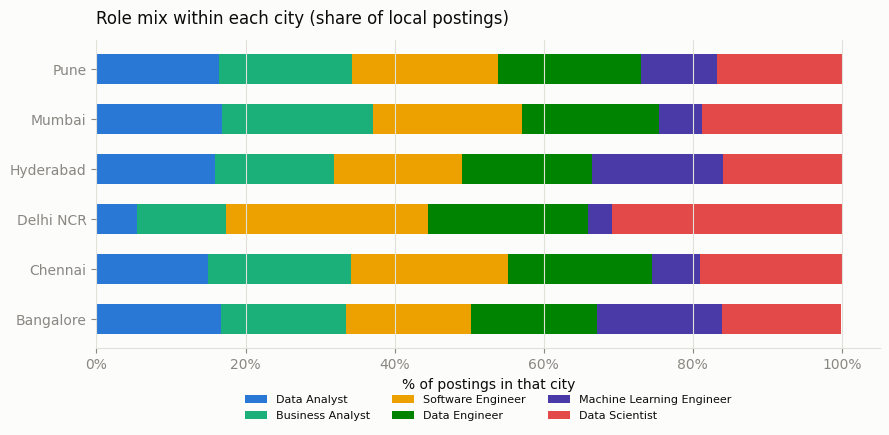

In [17]:
fig, ax = plt.subplots(figsize=(9, 4.5))
bottom = pd.Series(0, index=pivot.index)
for role in ROLE_ORDER:
    ax.barh(pivot.index, pivot[role], left=bottom, color=ROLE_COLORS[role], label=role, height=0.6)
    bottom += pivot[role]
ax.set_xlabel("% of postings in that city")
ax.set_title("Role mix within each city (share of local postings)", loc="left", pad=12, fontsize=12)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False, fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
plt.tight_layout()
plt.show()

**Insight:** Delhi NCR is disproportionately Data-Scientist- and
Software-Engineer-heavy (30.9% and 27.1% of its local postings respectively,
versus a roughly even ~16-17% split across all six roles in Bangalore and
Hyderabad) and has the **smallest Machine Learning Engineer share of any city**
(3.2%). If Machine Learning Engineer is the specific target role, **Pune is
proportionally the strongest market** (10.1% of its local postings) even though
Bangalore and Hyderabad have larger absolute totals — proportional concentration
and raw volume tell different stories, and a job-seeker optimizing for
competition-per-opening should look at the former.


## Key takeaways

1. **Python + SQL are the most broadly transferable skills** in this market —
   they place in the top skills for nearly every role, and co-occur with each
   other more than any other pair.
2. **Role choice affects pay more than city choice.** The role-level salary
   spread (~₹6L, ML Engineer to Business Analyst) dwarfs the city-level spread
   (~₹2L, Chennai to Hyderabad/Mumbai).
3. **The inferred seniority signal is trustworthy** — it produces a clean,
   monotonic salary gradient (Junior ₹7.0L → Mid ₹14.6L → Senior ₹17.3L)
   without ever being trained on salary, which is a meaningful validation of
   the NLP rule in `nlp/seniority.py`.
4. **ML/data-infrastructure skills (Airflow, GCP, Deep Learning) correlate with
   the highest pay**, but this is confounded with seniority — treat it as "these
   skills travel with better-paying postings," not a guaranteed salary lift.
5. Only ~23% of postings disclose salary at all — a real market-transparency
   finding in its own right, and the reason every salary insight above is
   scoped to that subset rather than claimed for the whole market.
